In [1]:
# !pip uninstall -y oceanttds

In [3]:
%load_ext autoreload
%autoreload 2
    
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
# import xgcm
import cartopy.crs as ccrs
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from oceanttds import * 
from tqdm.notebook import tqdm
import zarr
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")


In [4]:
import cmocean.cm as cmo

In [6]:
ds_path = "/proj/ecco/CM4X/budget_sigma2_v1.2.0/CM4Xp125_budgets_sigma2_2010-2014.zarr"
ds = xr.open_mfdataset(ds_path)

In [7]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/bottom_tracers_yearly.zarr"
ds = xr.open_mfdataset(ds_path)
ds = ds.sel(year = slice(None, 2099))
ds = ds.where(ds.depth < -2500)

In [8]:
ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/adelie_ross_boundary_sample_for_ttd.zarr"
ds_b = xr.open_mfdataset(ds_path).compute().rename({"year":"time", "__xarray_dataarray_variable__":"boundary_truth"}).fillna(0.0)
ds_b["boundary"] = ds_b["boundary_truth"].copy()

ds_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/adelie_ross_interior_sample_for_ttd.zarr"
ds_i = xr.open_mfdataset(ds_path).compute().rename({"year":"time", "__xarray_dataarray_variable__": "interior_truth"}).fillna(0.0)
ds_i = ds_i.sel(time = slice(1940, 2030))
ds_i["interior"] = ds_i["interior_truth"].copy()

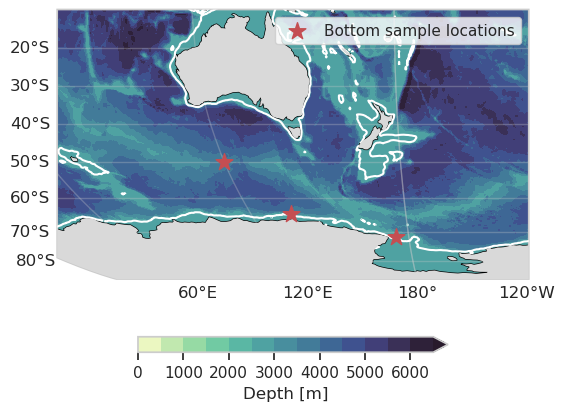

In [10]:
fig, ax = plt.subplots(
    figsize=(8, 5),
    subplot_kw=dict(projection=ccrs.Robinson(central_longitude=-165)),
)

depth = ds.deptho.where(ds.deptho > 10).compute()
levels = np.arange(0, 7000, 500)

pc = ax.contourf(ds["geolon"], ds["geolat"], depth,
                 transform=ccrs.PlateCarree(), levels = levels,extend = "max", 
                cmap = cmo.deep)
ax.contour(ds["geolon"], ds["geolat"], depth,
                 transform=ccrs.PlateCarree(), levels = [1000.0], colors = "white", zorder = 8)

ax.scatter(ds_b.sel(source = "ross").lon, ds_b.sel(source = "ross").lat,transform=ccrs.PlateCarree(), c="r", zorder=10,s = 160, marker = "*")
ax.scatter(ds_b.sel(source = "adelie").lon, ds_b.sel(source = "adelie").lat,transform=ccrs.PlateCarree(), c="r", zorder=10,s = 160, marker = "*")
ax.scatter(ds_i.lon, ds_i.lat,transform=ccrs.PlateCarree(), c="r", zorder=10,s = 160, marker = "*", label = "Bottom sample locations")

ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=8)
ax.coastlines()
# Australian Basin (approx): lon 80E–170E, lat 60S–10S
ax.set_extent([80, 220, -89, -10], crs=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True, alpha=0.3)
gl.top_labels = False
gl.right_labels = False
fig.colorbar(pc, ax = ax, orientation = "horizontal", shrink = 0.5, label = "Depth [m]")
legend = ax.legend(loc='upper right')

# Set the z-order of the legend (e.g., to a high value like 10)
legend.set_zorder(15) #
fig.savefig('plots/1.ttd_example_locations.png', dpi = 150, bbox_inches = "tight")